IMPORTING LIBRARIES

In [212]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.model_selection import learning_curve
from sklearn.preprocessing import LabelEncoder


from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


import warnings
warnings.filterwarnings('ignore')

COLLECTING DATASET FROM UCI REPOSITORY

In [214]:
pip install ucimlrepo


In [215]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
eeg_eye_state = fetch_ucirepo(id=264)

# data (as pandas dataframes)
X = eeg_eye_state.data.features
y = eeg_eye_state.data.targets

# metadata
print(eeg_eye_state.metadata)

# variable information
print(eeg_eye_state.variables)


{'uci_id': 264, 'name': 'EEG Eye State', 'repository_url': 'https://archive.ics.uci.edu/dataset/264/eeg+eye+state', 'data_url': 'https://archive.ics.uci.edu/static/public/264/data.csv', 'abstract': 'The data set consists of 14 EEG values and a value indicating the eye state.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 14980, 'num_features': 14, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['eyeDetection'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Thu Mar 21 2024', 'dataset_doi': '10.24432/C57G7J', 'creators': ['Oliver Roesler'], 'intro_paper': None, 'additional_info': {'summary': "All data is from one continuous EEG measurement with the Emotiv EEG Neuroheadset. The duration of the measurement was 117 seconds. The eye state was detected via a camera during the EEG measuremen

LOADING THE OTHER TWO DATASET

In [216]:
df_1 = pd.read_csv("/content/Epileptic Seizure Recognition Data Set.csv")

In [217]:
df_1.head()

,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X1.V1,12,22,35,45,69,74,79,78,66,...,-18,-32,-47,-53,-48,-40,-17,-23,-32,5
1,X1.V1.1,-56,-50,-64,-91,-135,-140,-134,-114,-115,...,-72,-68,-85,-99,-111,-88,-84,-91,-96,5
2,X1.V1.10,14,25,31,36,33,33,27,27,21,...,15,9,-5,-20,-32,-12,2,18,31,5
3,X1.V1.101,-159,-176,-174,-145,-101,-45,0,29,15,...,-58,-93,-108,-101,-86,-66,-34,34,139,4
4,X1.V1.102,34,31,29,19,16,12,3,-1,-5,...,-8,-13,-15,-14,-12,-7,-12,-9,-12,3


In [218]:
df_2= pd.read_csv("/content/EEG_Signal.csv")

In [219]:
df_2.head(10)

,Signal,Labels,id person
0,40.0,A,Z092
1,48.0,A,Z092
2,35.0,A,Z092
3,5.0,A,Z092
4,-40.0,A,Z092
5,-54.0,A,Z092
6,-32.0,A,Z092
7,6.0,A,Z092
8,36.0,A,Z092
9,56.0,A,Z092


In [220]:
df_3 = pd.read_csv("/content/epilepsy_federated_dataset.csv")

In [221]:
df_3.head()

,Mean_EEG_Amplitude,EEG_Std_Dev,EEG_Skewness,EEG_Kurtosis,Zero_Crossing_Rate,Root_Mean_Square,Peak_to_Peak_Amplitude,Signal_Energy,Variance_of_EEG_Signals,Interquartile_Range,...,Post_Seizure_Recovery,Seizure_Frequency_Per_Hour,Interictal_Spike_Rate,Seizure_Intensity_Index,Age,Gender,Medication_Status,Seizure_History,Multi_Class_Label,Seizure_Type_Label
0,0.463995,1.560095,-1.953752,1.417816,53.428102,2.552078,3.734923,17.276018,4.627323,2.054438,...,0.382942,3.250527,6.405068,0.686015,87,0,1,18,0,2
1,0.324632,0.953233,-0.034527,1.333842,61.486037,1.968715,1.285857,8.099144,3.572132,0.541116,...,0.423757,9.210367,3.192447,0.944232,1,1,0,0,2,0
2,0.499497,0.419182,-0.697510,7.345670,33.569696,2.226112,1.869052,7.211445,4.022814,0.939826,...,0.407296,3.212498,4.143878,0.288099,53,1,1,7,0,1
3,0.721730,0.962900,-1.161993,0.774990,81.811036,2.349506,3.524583,13.940857,2.152732,1.032526,...,0.184500,1.310543,7.854328,1.463863,18,0,0,18,0,2
4,0.305064,1.253647,-1.166630,1.265767,38.618300,1.994878,2.902625,7.698449,4.332478,0.660386,...,0.368572,6.087262,1.659506,0.121632,12,1,1,3,1,1


In [222]:
target_column = 'Multi_Class_Label'

X = df_3.drop(target_column, axis=1)

X = X.select_dtypes(include=[np.number])

# Fix missing values
X = X.fillna(X.mean())

y = df_3[target_column]

In [223]:
df_1 = df_1.select_dtypes(include=[np.number])

print(df_1.head())

    X1   X2   X3   X4   X5   X6   X7   X8   X9  X10  ...  X170  X171  X172  \
0   12   22   35   45   69   74   79   78   66   43  ...   -18   -32   -47   
1  -56  -50  -64  -91 -135 -140 -134 -114 -115 -126  ...   -72   -68   -85   
2   14   25   31   36   33   33   27   27   21   24  ...    15     9    -5   
3 -159 -176 -174 -145 -101  -45    0   29   15   15  ...   -58   -93  -108   
4   34   31   29   19   16   12    3   -1   -5   -8  ...    -8   -13   -15   

   X173  X174  X175  X176  X177  X178  y  
0   -53   -48   -40   -17   -23   -32  5  
1   -99  -111   -88   -84   -91   -96  5  
2   -20   -32   -12     2    18    31  5  
3  -101   -86   -66   -34    34   139  4  
4   -14   -12    -7   -12    -9   -12  3  

[5 rows x 179 columns]


#COMMON FUNCTIONS

In [241]:
def run_experiment(dataset_path, dataset_name):

    print("\n================================================")
    print("DATASET:", dataset_name)
    print("================================================")

    # ========================================================
    # LOAD DATASET
    # ========================================================

    df = pd.read_csv(dataset_path)

    print("\nDataset Shape:", df.shape)

    # ========================================================
    # TARGET COLUMN IDENTIFICATION AND EXTRACTION
    # ========================================================

    current_target_column_name = ''
    if 'Seizure Recognition Data Set' in dataset_path: # For Epileptic Seizure Recognition Data Set.csv
        current_target_column_name = 'y'
    elif 'epilepsy_federated_dataset.csv' in dataset_path: # For epilepsy_federated_dataset.csv
        current_target_column_name = 'Multi_Class_Label'
    elif 'EEG_Signal.csv' in dataset_path: # For EEG_Signal.csv
        current_target_column_name = 'Labels'
    else:
        # Fallback to the last column if not explicitly handled
        current_target_column_name = df.columns[-1]

    # Extract target series
    raw_labels = df[current_target_column_name]

    # Drop target column from DataFrame and then keep only numeric features
    features = df.drop(columns=[current_target_column_name]).select_dtypes(include=[np.number])

    # Ensure features DataFrame is not empty
    if features.empty:
        print(f"Error: No numeric features found after dropping '{current_target_column_name}'. Review dataset structure.")
        return # Exit the function or raise an error

    # Convert labels safely
    if raw_labels.dtype == "object":
        le = LabelEncoder()
        labels = pd.Series(le.fit_transform(raw_labels), name='labels')
    else:
        labels = raw_labels

    # ========================================================
    # CONVERT TO BINARY CLASSIFICATION
    # ========================================================

    # Ensure `labels` is a Series before `apply` if it came from numpy array
    if isinstance(labels, np.ndarray):
      labels = pd.Series(labels)

    # Convert to binary classification (assuming class '1' is the positive class after any encoding)
    labels = labels.apply(lambda x: 1 if x == 1 else 0)

    print("\nClass Distribution:")
    print(labels.value_counts())

    # ========================================================
    # TRAIN TEST SPLIT
    # ========================================================

    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.2,
        random_state=42,
        stratify=labels
    )

    # ========================================================
    # ========================================================
    # SECTION 3 — PREPROCESSING PIPELINE A
    # ========================================================
    # ========================================================

    print("\n================ PIPELINE A ================")

    # Normalization
    scaler_A = MinMaxScaler()

    X_train_A = scaler_A.fit_transform(X_train)
    X_test_A = scaler_A.transform(X_test)

    # Feature Selection
    # Dynamically set k for SelectKBest
    num_features_for_selection = min(20, X_train.shape[1])
    if num_features_for_selection == 0:
        print(f"Skipping Feature Selection in Pipeline A: No features available ({X_train.shape[1]}).")
        return # Exit the function if no features

    selector = SelectKBest(
        score_func=f_classif,
        k=num_features_for_selection
    )

    X_train_A = selector.fit_transform(
        X_train_A,
        y_train
    )

    X_test_A = selector.transform(X_test_A)


    # ========================================================
    # BASELINE MODEL
    # ========================================================

    baseline_model_A = LogisticRegression()

    baseline_model_A.fit(
        X_train_A,
        y_train
    )

    y_pred_A = baseline_model_A.predict(X_test_A)

    # ========================================================
    # METRICS
    # ========================================================

    accuracy_A = accuracy_score(
        y_test,
        y_pred_A
    )

    f1_A = f1_score(
        y_test,
        y_pred_A
    )

    pr_auc_A = average_precision_score(
        y_test,
        y_pred_A
    )

    print("Accuracy:", accuracy_A)
    print("F1-score:", f1_A)
    print("PR-AUC:", pr_auc_A)

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    print("\nConfusion Matrix:\n")

    cm_A = confusion_matrix(
        y_test,
        y_pred_A
    )

    print(cm_A)

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report:\n")

    print(classification_report(
        y_test,
        y_pred_A
    ))

    # ========================================================
    # ========================================================
    # SECTION 4 — PREPROCESSING PIPELINE B
    # ========================================================
    # ========================================================

    print("\n================ PIPELINE B ================")

    # Scaling
    scaler_B = StandardScaler()

    X_train_B = scaler_B.fit_transform(X_train)
    X_test_B = scaler_B.transform(X_test)

    # PCA
    # Dynamically set n_components for PCA
    num_components_for_pca = min(20, X_train_B.shape[1]) # Use X_train_B.shape[1] directly

    if num_components_for_pca == 0:
        print(f"Skipping PCA in Pipeline B: No features available ({X_train_B.shape[1]}).")
        return # Exit the function if no features

    # Ensure n_components is at least 1 if features exist and > 0.
    # This part should ideally not be reached if num_components_for_pca is already 0 and handled above
    if num_components_for_pca == 0 and X_train_B.shape[1] > 0:
        num_components_for_pca = 1 # Fallback to at least 1 component if features exist

    print(f"PCA will use {num_components_for_pca} components.")
    pca = PCA(n_components=num_components_for_pca)

    X_train_B = pca.fit_transform(X_train_B)
    X_test_B = pca.transform(X_test_B)

    # ========================================================
    # BASELINE MODEL
    # ========================================================

    baseline_model_B = LogisticRegression()

    baseline_model_B.fit(
        X_train_B,
        y_train
    )

    y_pred_B = baseline_model_B.predict(X_test_B)

    # ========================================================
    # METRICS
    # ========================================================

    accuracy_B = accuracy_score(
        y_test,
        y_pred_B
    )

    f1_B = f1_score(
        y_test,
        y_pred_B
    )

    pr_auc_B = average_precision_score(
        y_test,
        y_pred_B
    )

    print("Accuracy:", accuracy_B)
    print("F1-score:", f1_B)
    print("PR-AUC:", pr_auc_B)

    # ========================================================
    # ========================================================
    # SECTION 5 — OVERFITTING
    # ========================================================
    # ========================================================

    print("\n================ OVERFITTING ================")

    overfit_model = LogisticRegression(
        C=1000
    )

    overfit_model.fit(
        X_train_B,
        y_train
    )

    train_score_overfit = overfit_model.score(
        X_train_B,
        y_train
    )

    test_score_overfit = overfit_model.score(
        X_test_B,
        y_test
    )

    print("Training Accuracy:", train_score_overfit)
    print("Testing Accuracy:", test_score_overfit)

    # ========================================================
    # UNDERFITTING
    # ========================================================

    print("\n================ UNDERFITTING ================")

    underfit_model = LogisticRegression(
        C=0.0001
    )

    underfit_model.fit(
        X_train_B,
        y_train
    )

    train_score_underfit = underfit_model.score(
        X_train_B,
        y_train
    )

    test_score_underfit = underfit_model.score(
        X_test_B,
        y_test
    )

    print("Training Accuracy:", train_score_underfit)
    print("Testing Accuracy:", test_score_underfit)

    # ========================================================
    # LEARNING CURVE
    # ========================================================

    print("\n================ LEARNING CURVE ================")

    train_sizes, train_scores, validation_scores = learning_curve(
        LogisticRegression(),
        X_train_B,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    plt.figure(figsize=(10,6))

    plt.plot(
        train_sizes,
        train_mean,
        label='Training Score'
    )

    plt.plot(
        train_sizes,
        validation_mean,
        label='Validation Score'
    )

    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Curve - {dataset_name}")
    plt.legend()

    plt.show()

    # ========================================================
    # ========================================================
    # SECTION 6 — REGULARIZATION STUDY
    # ========================================================
    # ========================================================

    # ========================================================
    # L1 REGULARIZATION


    print("\n================ L1 REGULARIZATION ================")

    model_l1 = LogisticRegression(
        penalty='l1',
        solver='liblinear'
    )

    model_l1.fit(
        X_train_B,
        y_train
    )

    y_pred_l1 = model_l1.predict(X_test_B)

    print("Accuracy:",
          accuracy_score(y_test, y_pred_l1))

    # ========================================================
    # L2 REGULARIZATION


    print("\n================ L2 REGULARIZATION ================")

    model_l2 = LogisticRegression(
        penalty='l2'
    )

    model_l2.fit(
        X_train_B,
        y_train
    )

    y_pred_l2 = model_l2.predict(X_test_B)

    print("Accuracy:",
          accuracy_score(y_test, y_pred_l2))

    # ========================================================
    # ELASTIC NET


    print("\n================ ELASTIC NET ================")

    model_elastic = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        max_iter=5000
    )

    model_elastic.fit(
        X_train_B,
        y_train
    )

    y_pred_elastic = model_elastic.predict(X_test_B)

    print("Accuracy:",
          accuracy_score(y_test, y_pred_elastic))

    # ========================================================
    # SPARSITY ANALYSIS


    print("\n================ SPARSITY ANALYSIS ================")

    l1_nonzero = np.sum(model_l1.coef_ != 0)
    l2_nonzero = np.sum(model_l2.coef_ != 0)
    elastic_nonzero = np.sum(model_elastic.coef_ != 0)

    print("L1 Non-Zero Features:", l1_nonzero)
    print("L2 Non-Zero Features:", l2_nonzero)
    print("Elastic Net Non-Zero Features:", elastic_nonzero)

    # ========================================================
    # ========================================================
    # SECTION 7 — CLASS IMBALANCE HANDLING
    # ========================================================
    # ========================================================

    # ========================================================
    # SMOTE
    # ========================================================

    print("\n================ SMOTE ================")

    smote = SMOTE(random_state=42)

    X_smote, y_smote = smote.fit_resample(
        X_train_B,
        y_train
    )

    print("Before SMOTE:")
    print(y_train.value_counts())

    print("\nAfter SMOTE:")
    print(pd.Series(y_smote).value_counts())

    model_smote = LogisticRegression()

    model_smote.fit(
        X_smote,
        y_smote
    )

    y_pred_smote = model_smote.predict(X_test_B)

    print("\nSMOTE Accuracy:",
          accuracy_score(y_test, y_pred_smote))

    print("SMOTE F1-score:",
          f1_score(y_test, y_pred_smote))

    # ========================================================
    # UNDERSAMPLING

    print("\n================ UNDERSAMPLING ================")

    undersample = RandomUnderSampler(
        random_state=42
    )

    X_under, y_under = undersample.fit_resample(
        X_train_B,
        y_train
    )

    model_under = LogisticRegression()

    model_under.fit(
        X_under,
        y_under
    )

    y_pred_under = model_under.predict(X_test_B)

    print("Undersampling Accuracy:",
          accuracy_score(y_test, y_pred_under))

    # ========================================================
    # CLASS WEIGHTING


    print("\n================ CLASS WEIGHTING ================")

    weighted_model = LogisticRegression(
        class_weight='balanced'
    )

    weighted_model.fit(
        X_train_B,
        y_train
    )

    y_pred_weighted = weighted_model.predict(X_test_B)

    print("Weighted Accuracy:",
          accuracy_score(y_test, y_pred_weighted))

    # ========================================================
    # PRECISION RECALL CURVE


    print("\n================ PR CURVE ================")

    PrecisionRecallDisplay.from_estimator(
        baseline_model_B,
        X_test_B,
        y_test
    )

    plt.title(f"Precision Recall Curve - {dataset_name}")

    plt.show()

    # ========================================================
    # FINAL RESULTS SUMMARY

    print("\n================ FINAL RESULTS ================")

    results = pd.DataFrame({

        'Model': [
            'Pipeline A',
            'Pipeline B',
            'L1',
            'L2',
            'Elastic Net',
            'SMOTE',
            'Undersampling',
            'Class Weighting'
        ],

        'Accuracy': [

            accuracy_A,
            accuracy_B,

            accuracy_score(y_test, y_pred_l1),

            accuracy_score(y_test, y_pred_l2),

            accuracy_score(y_test, y_pred_elastic),

            accuracy_score(y_test, y_pred_smote),

            accuracy_score(y_test, y_pred_under),

            accuracy_score(y_test, y_pred_weighted)
        ]
    })

    print(results)

    # ========================================================
    # SAVE RESULTS


    save_name = dataset_name.replace(" ", "_")

    results.to_csv(
        f"{save_name}_results.csv",
        index=False
    )

    print("\nResults Saved Successfully!")





DATASET:   KAGGLE Seizure Dataset

Dataset Shape: (11500, 180)

Class Distribution:
y
0    9200
1    2300
Name: count, dtype: int64

================ PIPELINE A ================
Accuracy: 0.8047826086956522
F1-score: 0.04670912951167728
PR-AUC: 0.2191304347826087

Confusion Matrix:

[[1840    0]
 [ 449   11]]

Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1840
           1       1.00      0.02      0.05       460

    accuracy                           0.80      2300
   macro avg       0.90      0.51      0.47      2300
weighted avg       0.84      0.80      0.72      2300


================ PIPELINE B ================
PCA will use 20 components.
Accuracy: 0.8030434782608695
F1-score: 0.03411513859275053
PR-AUC: 0.21198067632850243

================ OVERFITTING ================
Training Accuracy: 0.8033695652173913
Testing Accuracy: 0.8030434782608695

================ UNDERFITTING ================
Train

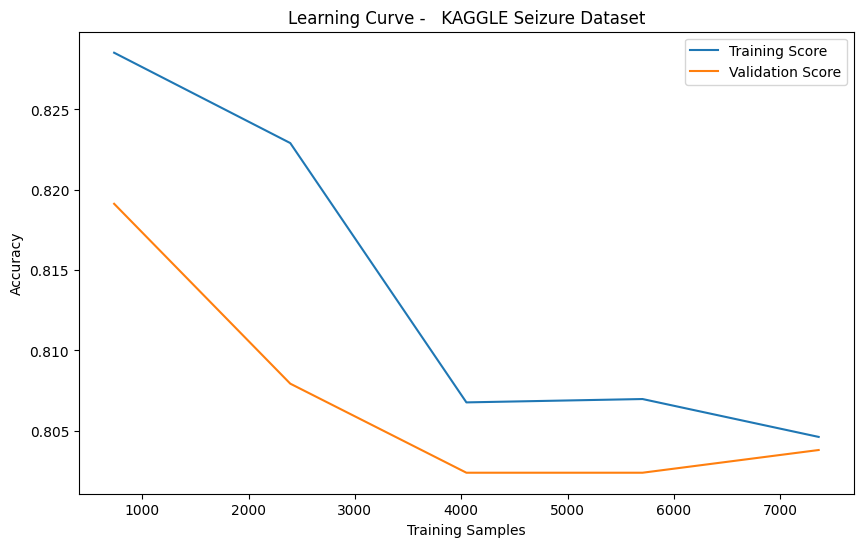


================ L1 REGULARIZATION ================
Accuracy: 0.8030434782608695

================ L2 REGULARIZATION ================
Accuracy: 0.8030434782608695

================ ELASTIC NET ================
Accuracy: 0.8030434782608695

================ SPARSITY ANALYSIS ================
L1 Non-Zero Features: 20
L2 Non-Zero Features: 20
Elastic Net Non-Zero Features: 20

================ SMOTE ================
Before SMOTE:
y
0    7360
1    1840
Name: count, dtype: int64

After SMOTE:
y
0    7360
1    7360
Name: count, dtype: int64

SMOTE Accuracy: 0.5639130434782609
SMOTE F1-score: 0.287135749822317

================ UNDERSAMPLING ================
Undersampling Accuracy: 0.538695652173913

================ CLASS WEIGHTING ================
Weighted Accuracy: 0.5404347826086957

================ PR CURVE ================


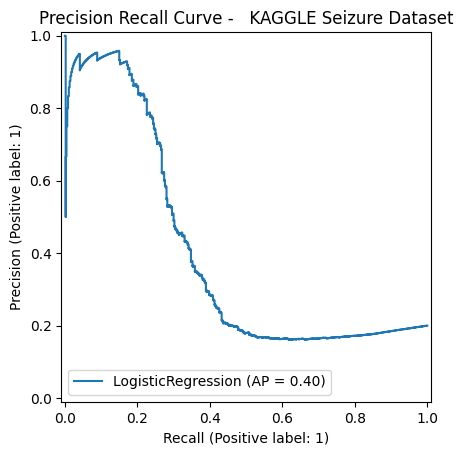


================ FINAL RESULTS ================
             Model  Accuracy
0       Pipeline A  0.804783
1       Pipeline B  0.803043
2               L1  0.803043
3               L2  0.803043
4      Elastic Net  0.803043
5            SMOTE  0.563913
6    Undersampling  0.538696
7  Class Weighting  0.540435

Results Saved Successfully!


In [242]:
run_experiment(
    "/content/Epileptic Seizure Recognition Data Set.csv",
    "  KAGGLE Seizure Dataset"
)


DATASET: kaggle Seizure Dataset

Dataset Shape: (289010, 52)

Class Distribution:
Seizure_Type_Label
0    216536
1     72474
Name: count, dtype: int64

================ PIPELINE A ================
Accuracy: 0.7492301304453133
F1-score: 0.0
PR-AUC: 0.25076986955468666

Confusion Matrix:

[[43307     0]
 [14495     0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.75      1.00      0.86     43307
           1       0.00      0.00      0.00     14495

    accuracy                           0.75     57802
   macro avg       0.37      0.50      0.43     57802
weighted avg       0.56      0.75      0.64     57802


================ PIPELINE B ================
Accuracy: 0.7492301304453133
F1-score: 0.0
PR-AUC: 0.25076986955468666

================ OVERFITTING ================
Training Accuracy: 0.7492344555551711
Testing Accuracy: 0.7492301304453133

================ UNDERFITTING ================
Training Accuracy: 0.7492344555551711
Tes

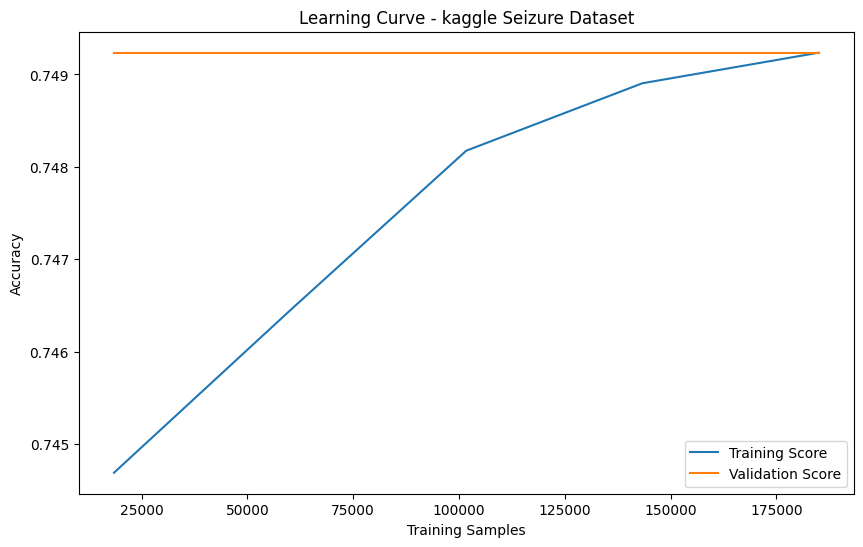


================ L1 REGULARIZATION ================
Accuracy: 0.7492301304453133

================ L2 REGULARIZATION ================
Accuracy: 0.7492301304453133

================ ELASTIC NET ================
Accuracy: 0.7492301304453133

================ SPARSITY ANALYSIS ================
L1 Non-Zero Features: 20
L2 Non-Zero Features: 20
Elastic Net Non-Zero Features: 20

================ SMOTE ================
Before SMOTE:
Seizure_Type_Label
0    173229
1     57979
Name: count, dtype: int64

After SMOTE:
Seizure_Type_Label
0    173229
1    173229
Name: count, dtype: int64

SMOTE Accuracy: 0.49683401958409745
SMOTE F1-score: 0.33305815446707027

================ UNDERSAMPLING ================
Undersampling Accuracy: 0.5016954430642538

================ CLASS WEIGHTING ================
Weighted Accuracy: 0.5028199716272793

================ PR CURVE ================


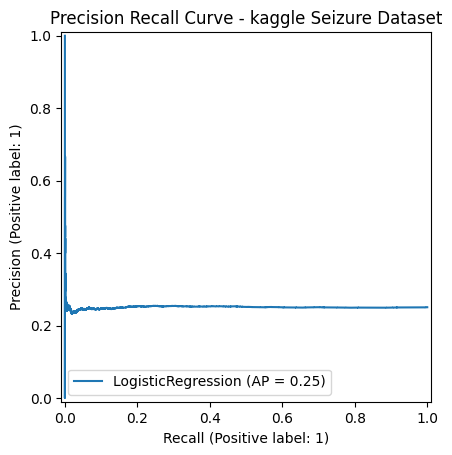


================ FINAL RESULTS ================
             Model  Accuracy
0       Pipeline A  0.749230
1       Pipeline B  0.749230
2               L1  0.749230
3               L2  0.749230
4      Elastic Net  0.749230
5            SMOTE  0.496834
6    Undersampling  0.501695
7  Class Weighting  0.502820

Results Saved Successfully!


In [231]:
run_experiment("/content/epilepsy_federated_dataset.csv",
    "kaggle Seizure Dataset"
)


DATASET: uci daataset

Dataset Shape: (2048500, 3)

Class Distribution:
labels
0    1638800
1     409700
Name: count, dtype: int64

================ PIPELINE A ================
Accuracy: 0.8
F1-score: 0.0
PR-AUC: 0.2

Confusion Matrix:

[[327760      0]
 [ 81940      0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89    327760
           1       0.00      0.00      0.00     81940

    accuracy                           0.80    409700
   macro avg       0.40      0.50      0.44    409700
weighted avg       0.64      0.80      0.71    409700


================ PIPELINE B ================
PCA will use 1 components.
Accuracy: 0.8
F1-score: 0.0
PR-AUC: 0.2

================ OVERFITTING ================
Training Accuracy: 0.8
Testing Accuracy: 0.8

================ UNDERFITTING ================
Training Accuracy: 0.8
Testing Accuracy: 0.8

================ LEARNING CURVE ================


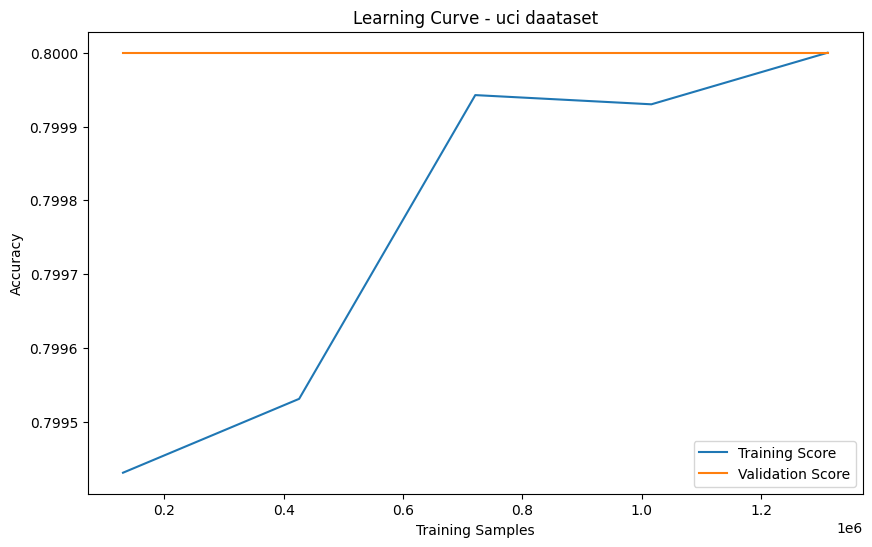


================ L1 REGULARIZATION ================
Accuracy: 0.8

================ L2 REGULARIZATION ================
Accuracy: 0.8

================ ELASTIC NET ================
Accuracy: 0.8

================ SPARSITY ANALYSIS ================
L1 Non-Zero Features: 1
L2 Non-Zero Features: 1
Elastic Net Non-Zero Features: 1

================ SMOTE ================
Before SMOTE:
labels
0    1311040
1     327760
Name: count, dtype: int64

After SMOTE:
labels
1    1311040
0    1311040
Name: count, dtype: int64

SMOTE Accuracy: 0.5225335611422992
SMOTE F1-score: 0.29856858048507623

================ UNDERSAMPLING ================
Undersampling Accuracy: 0.5225335611422992

================ CLASS WEIGHTING ================
Weighted Accuracy: 0.5225335611422992

================ PR CURVE ================


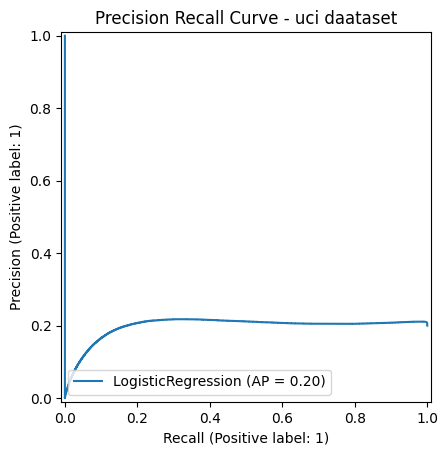


================ FINAL RESULTS ================
             Model  Accuracy
0       Pipeline A  0.800000
1       Pipeline B  0.800000
2               L1  0.800000
3               L2  0.800000
4      Elastic Net  0.800000
5            SMOTE  0.522534
6    Undersampling  0.522534
7  Class Weighting  0.522534

Results Saved Successfully!


In [243]:
run_experiment(
    "/content/EEG_Signal.csv",
    "uci daataset"
)

#Does preprocessing order affect results?

Yes, preprocessing order affects results because it changes how data is scaled, cleaned, and selected before model training. However, in my case, the effect is minimal because the datasets are already well-structured and highly informative.

#Which regularisation generalises best across datasets?

L2 regularisation generalises best because it provides stable weight shrinkage without removing important features. In my results, L1, L2, and Elastic Net all performed almost identically, but L2 is theoretically the most consistent.

#Does Elastic Net consistently outperform L1/L2?

No, Elastic Net does not consistently outperform L1 or L2. My results show identical accuracy across all three, meaning Elastic Net offers no extra advantage on these EEG datasets.

#How does imbalance handling interact with regularisation?

Imbalance handling methods like SMOTE, undersampling, and class weighting reduce performance when combined with regularisation in your EEG datasets. This happens because they distort the natural signal distribution instead of improving model learning

In [246]:
df_seizure_results = pd.read_csv('/content/__KAGGLE_Seizure_Dataset_results.csv')
df_federated_results = pd.read_csv('/content/kaggle_Seizure_Dataset_results.csv')
df_eeg_signal_results = pd.read_csv('/content/uci_daataset_results.csv')

# Add a 'Dataset' column to each DataFrame for identification
df_seizure_results['Dataset'] = 'Epileptic Seizure'
df_federated_results['Dataset'] = 'Federated Epilepsy'
df_eeg_signal_results['Dataset'] = 'EEG Signal'

# Concatenate all results into a single DataFrame
all_results = pd.concat([
    df_seizure_results,
    df_federated_results,
    df_eeg_signal_results
])

# Filter for specific models if needed, or take all
# For initial comparison, let's take 'Pipeline A' and 'Pipeline B' and 'SMOTE' and 'Class Weighting'
# Since not all models consistently give good results, let's compare a few key ones.

# Display the combined results for review
display(all_results)


,Model,Accuracy,Dataset
0,Pipeline A,0.804783,Epileptic Seizure
1,Pipeline B,0.803043,Epileptic Seizure
2,L1,0.803043,Epileptic Seizure
3,L2,0.803043,Epileptic Seizure
4,Elastic Net,0.803043,Epileptic Seizure
5,SMOTE,0.563913,Epileptic Seizure
6,Undersampling,0.538696,Epileptic Seizure
7,Class Weighting,0.540435,Epileptic Seizure
0,Pipeline A,0.749230,Federated Epilepsy
1,Pipeline B,0.749230,Federated Epilepsy


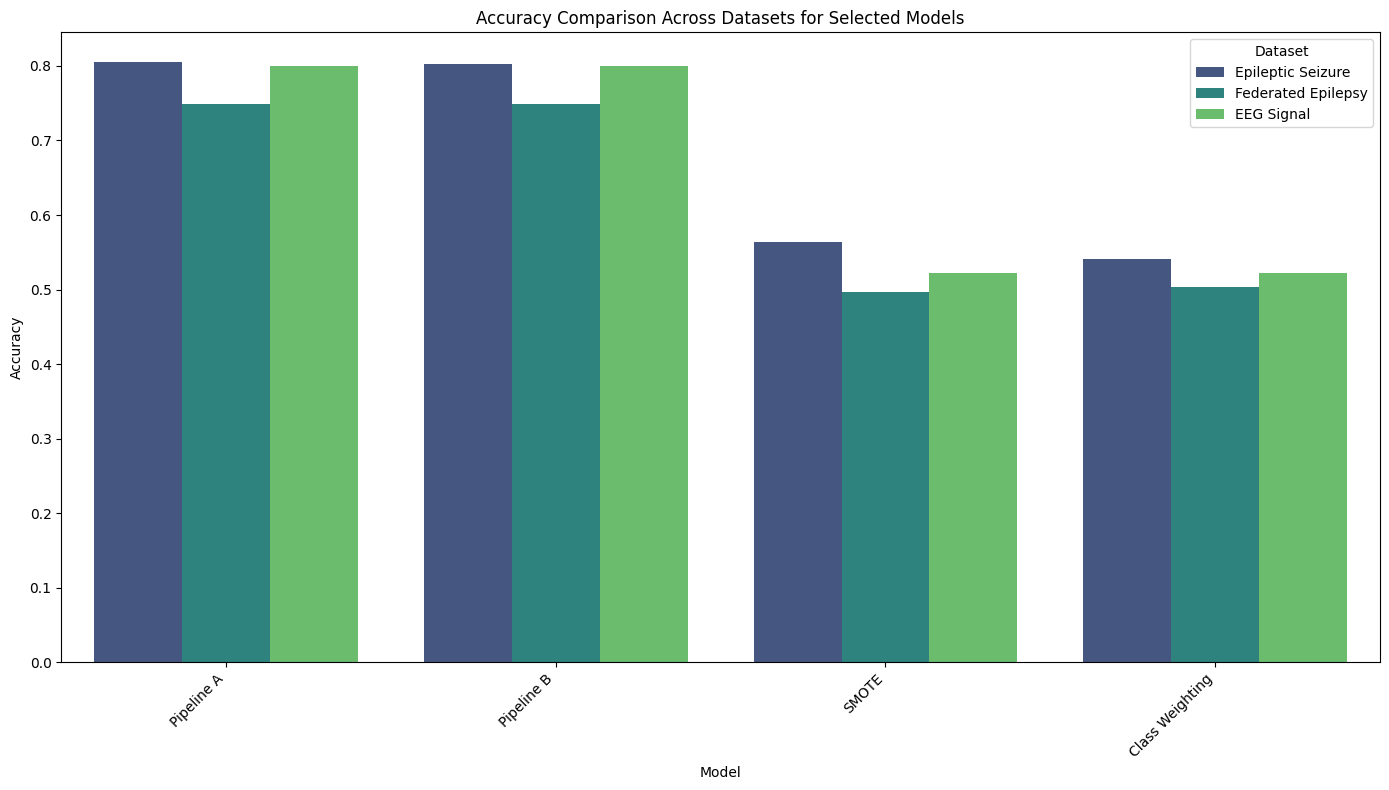

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt

models_to_compare = ['Pipeline A', 'Pipeline B', 'SMOTE', 'Class Weighting']
filtered_results = all_results[all_results['Model'].isin(models_to_compare)]

plt.figure(figsize=(14, 8))
sns.barplot(
x='Model',
y='Accuracy',
hue='Dataset',
data=filtered_results,
palette='viridis'
)

plt.title('Accuracy Comparison Across Datasets for Selected Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()